# Experiment 1 — Cotton Plant Disease Classification with a Custom CNN

This notebook trains a six-class cotton leaf disease classifier using a custom convolutional neural network on the **4,788-image** main dataset.

The experiment uses: 256×256 RGB images, batch size 32, 100 maximum epochs, Adam, sparse categorical cross-entropy, random horizontal-and-vertical flips, random rotation of 0.2, and early stopping on validation loss with patience 10.

The dataset is divided into: **120 training batches, 15 validation batches, and 15 test batches**, corresponding to **3,840 training images, 480 validation images, and 468 test images**. This preserves the intended batch-level training, validation, and test partitions.

The evaluation reports balanced accuracy, macro and weighted precision/recall/F1, a classification report, confusion matrices, and test errors.


## 1. Imports and runtime information

Select a Kaggle GPU accelerator before running this notebook. The P100 is sufficient for this custom CNN.


In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration and dataset path

The path detection supports both common Kaggle input layouts. The class order is explicitly fixed to match this experiment.


In [2]:
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 100
NUM_CLASSES = 6

EXPECTED_TOTAL_IMAGES = 4788
EXPECTED_TRAIN_IMAGES = 3840
EXPECTED_VAL_IMAGES = 480
EXPECTED_TEST_IMAGES = 468

CLASS_NAMES = [
    "Aphids",
    "Army worm",
    "Bacterial blight",
    "Healthy",
    "Powdery mildew",
    "Target spot",
]

CANDIDATE_ROOTS = [
    Path("/kaggle/input/cotton-plant-disease/Cotton leaves/40 Images"),
    Path("/kaggle/input/datasets/dhamur/cotton-plant-disease/Cotton leaves/40 Images"),
]
DATA_ROOT = next((p for p in CANDIDATE_ROOTS if p.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find the dataset. Add dhamur/cotton-plant-disease to the Kaggle notebook inputs."
    )

OUTPUT_DIR = Path("/kaggle/working/cotton_v1_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATA_ROOT)
print("Output directory:", OUTPUT_DIR)


Dataset root: /kaggle/input/datasets/dhamur/cotton-plant-disease/Cotton leaves/40 Images
Output directory: /kaggle/working/cotton_v1_outputs


## 3. Load the same main dataset

This is intentionally the same loader configuration as this experiment. TensorFlow reports the number of files and classes, and the assertions prevent accidentally loading one of the processed folders.


In [3]:
dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    seed=SEED,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)

class_names = dataset.class_names
print("Class names from directory:", class_names)
print("Expected class names:", CLASS_NAMES)
assert class_names == CLASS_NAMES, (class_names, CLASS_NAMES)

num_batches = tf.data.experimental.cardinality(dataset).numpy()
print("Total batches:", num_batches)
print("Expected batches: 150")
assert num_batches == 150
assert EXPECTED_TOTAL_IMAGES == 149 * BATCH_SIZE + 20


Found 4788 files belonging to 6 classes.


I0000 00:00:1787168997.006788      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Class names from directory: ['Aphids', 'Army worm', 'Bacterial blight', 'Healthy', 'Powdery mildew', 'Target spot']
Expected class names: ['Aphids', 'Army worm', 'Bacterial blight', 'Healthy', 'Powdery mildew', 'Target spot']
Total batches: 150
Expected batches: 150


## 4. Inspect one batch


Image batch shape: (32, 256, 256, 3)
Label batch shape: (32,)
Labels: [3 5 2 0 5 5 2 2 3 2 4 4 5 2 4 1 3 2 2 1 0 5 5 1 3 5 5 3 4 2 5 3]


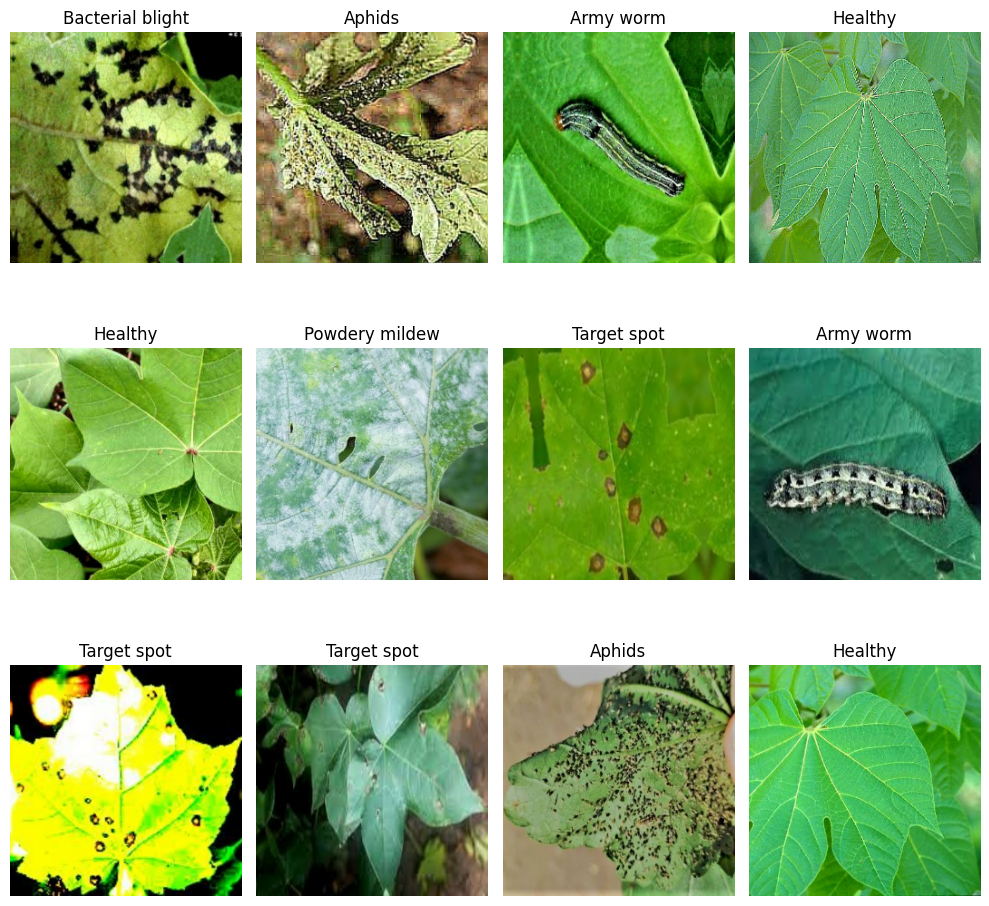

In [4]:
for image_batch, labels_batch in dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", labels_batch.shape)
    print("Labels:", labels_batch.numpy())

plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(min(12, len(image_batch))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels_batch[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()


## 5. Reproduce the batch-level split

This experiment uses 80% of the 150 batches for training, then 10% for validation, with the remainder for testing. Because the final dataset batch contains 20 images, the exact image counts are 3,840 / 480 / 468.


In [5]:
train_dataset = dataset.take(120)
remaining_dataset = dataset.skip(120)
val_dataset = remaining_dataset.take(15)
test_dataset = remaining_dataset.skip(15)

print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

assert 120 * BATCH_SIZE == EXPECTED_TRAIN_IMAGES
assert 15 * BATCH_SIZE == EXPECTED_VAL_IMAGES
assert EXPECTED_TOTAL_IMAGES - EXPECTED_TRAIN_IMAGES - EXPECTED_VAL_IMAGES == EXPECTED_TEST_IMAGES


Train batches: 120
Validation batches: 15
Test batches: 15


## 6. Optimize the input pipeline and apply the augmentation

This experiment caches, shuffles, and prefetches the datasets. Augmentation is applied only to training data, exactly as in the experiment. Validation and test data are not augmented.


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000, seed=SEED, reshuffle_each_iteration=True).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255.0),
], name="resize_and_rescale")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
], name="data_augmentation")

train_dataset = train_dataset.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)


## 7. Build the custom CNN

This is the same architecture as this experiment: six convolutional blocks with 32/64 filters, max pooling after every convolution, a 64-unit dense layer, and a six-class softmax output. The input-shape declaration is written in the current Keras form without changing the architecture.


In [7]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="cotton_original_cnn")

model.build((None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cotton_original_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resize_and_rescale (Sequential) │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,942 (718.52 KB)

 Trainable params: 183,942 (718.52 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile and train

The optimizer, loss, maximum epoch count, and early-stopping behavior match the experiment. A checkpoint is also saved so the best validation-loss model can be restored after training.


In [8]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    OUTPUT_DIR / "v1_original_cnn_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1,
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    verbose=1,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
)


Epoch 1/100
  5/120 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2129 - loss: 1.7884 

I0000 00:00:1787169021.258357     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.2695 - loss: 1.6576
Epoch 1: val_loss improved from None to 1.22856, saving model to /kaggle/working/cotton_v1_outputs/v1_original_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/cotton_v1_outputs/v1_original_cnn_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 42s 182ms/step - accuracy: 0.3961 - loss: 1.4536 - val_accuracy: 0.5417 - val_loss: 1.2286
Epoch 2/100
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5884 - loss: 1.0485
Epoch 2: val_loss improved from 1.22856 to 0.96620, saving model to /kaggle/working/cotton_v1_outputs/v1_original_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/cotton_v1_outputs/v1_original_cnn_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 114ms/step - accuracy: 0.5997 - loss: 1.0329 - val_accuracy: 0.6167 - val_loss: 0.9662
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6440 - loss: 0.9627
Epoch 3: val_loss did not improve from 0.96620
120/120 ━━━

## 9. Plot training history


,accuracy,loss,val_accuracy,val_loss
50,0.971615,0.081234,0.937500,0.226420
51,0.972917,0.078932,0.952083,0.251528
52,0.976302,0.073387,0.931250,0.384616
53,0.971875,0.096356,0.939583,0.328826
54,0.979167,0.065721,0.947917,0.306286


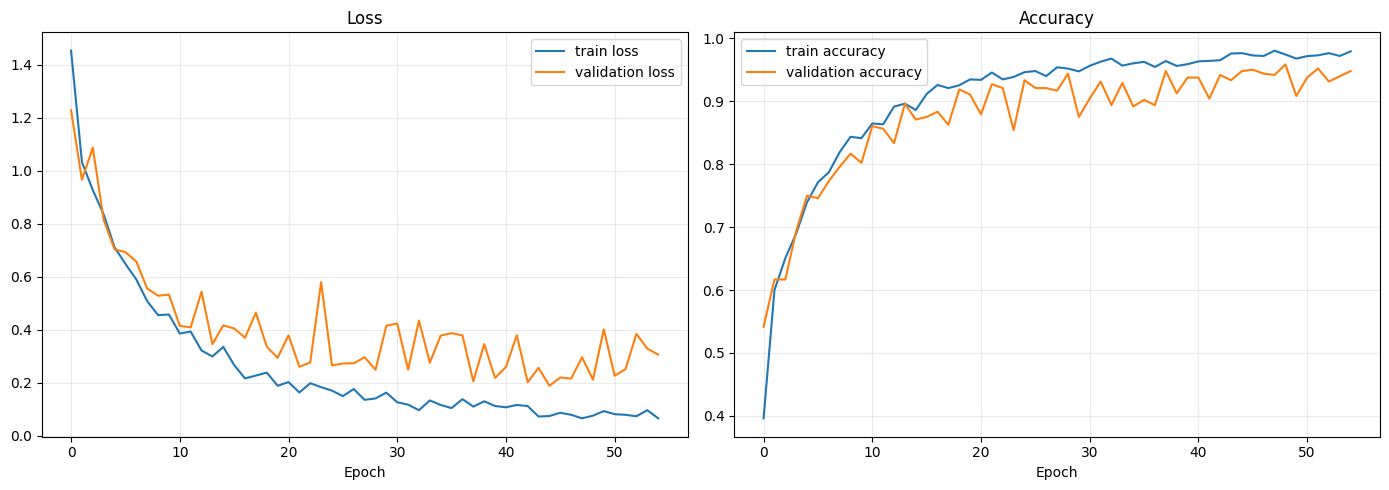

In [9]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="validation loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="validation accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 10. Evaluate on the test set with the complete metric suite

The labels and predictions are collected in the same single pass through `test_dataset`, so they remain aligned even though the original dataset was shuffled. This reports the same family of metrics used for the experiment rather than accuracy alone.


In [10]:
y_true_parts = []
y_prob_parts = []

for images, labels in test_dataset:
    probabilities = model(images, training=False).numpy()
    y_true_parts.append(labels.numpy())
    y_prob_parts.append(probabilities)

y_true = np.concatenate(y_true_parts)
y_prob = np.concatenate(y_prob_parts)
y_pred = np.argmax(y_prob, axis=1)

print("Test images evaluated:", len(y_true))
assert len(y_true) == EXPECTED_TEST_IMAGES

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}

print(pd.Series(metrics).round(4))


Test images evaluated: 468
accuracy              0.9573
balanced_accuracy     0.9564
macro_precision       0.9568
macro_recall          0.9564
macro_f1              0.9564
weighted_precision    0.9575
weighted_recall       0.9573
weighted_f1           0.9572
dtype: float64


## 11. Per-class classification report


,precision,recall,f1-score,support
Aphids,0.9467,0.9861,0.9660,72.0000
Army worm,0.9730,0.9600,0.9664,75.0000
Bacterial blight,0.9577,0.9189,0.9379,74.0000
Healthy,0.9425,0.9762,0.9591,84.0000
Powdery mildew,0.9885,0.9773,0.9829,88.0000
Target spot,0.9324,0.9200,0.9262,75.0000
accuracy,0.9573,0.9573,0.9573,0.9573
macro avg,0.9568,0.9564,0.9564,468.0000
weighted avg,0.9575,0.9573,0.9572,468.0000


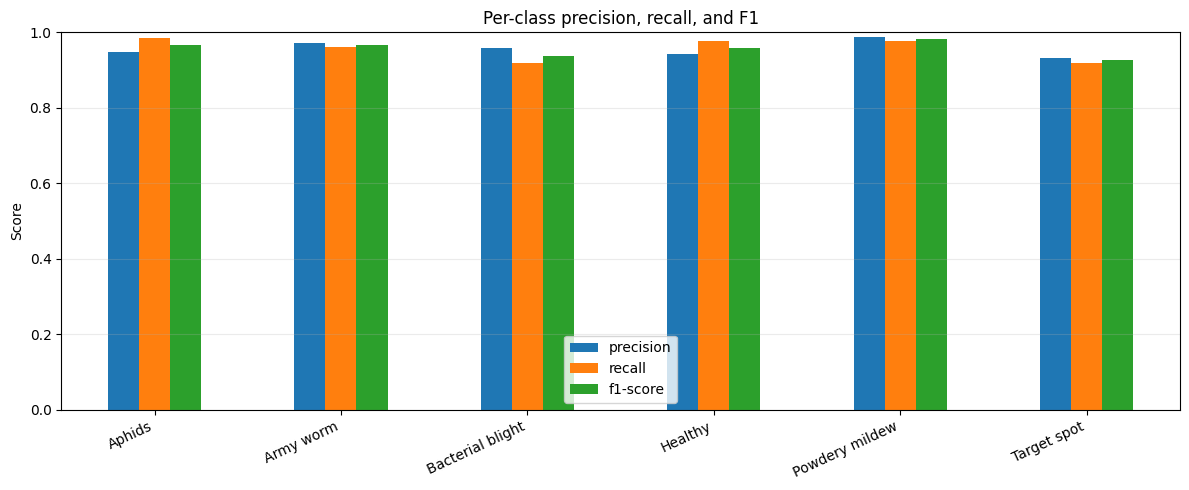

In [11]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.round(4))

per_class_df = report_df.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]
per_class_df[["precision", "recall", "f1-score"]].plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1),
    title="Per-class precision, recall, and F1",
)
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 12. Confusion matrices


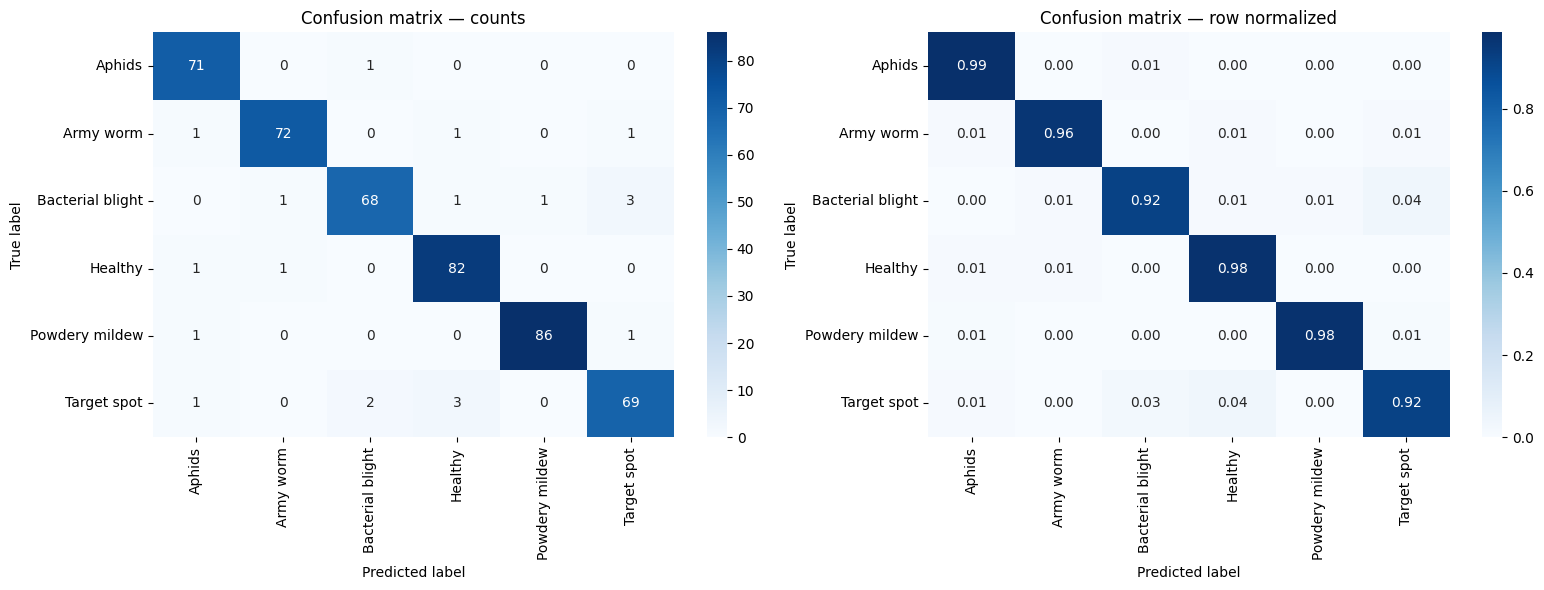

In [12]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
cm_normalized = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_title("Confusion matrix — counts")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_title("Confusion matrix — row normalized")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()


## 13. Inspect test errors and confidence


Test errors: 20


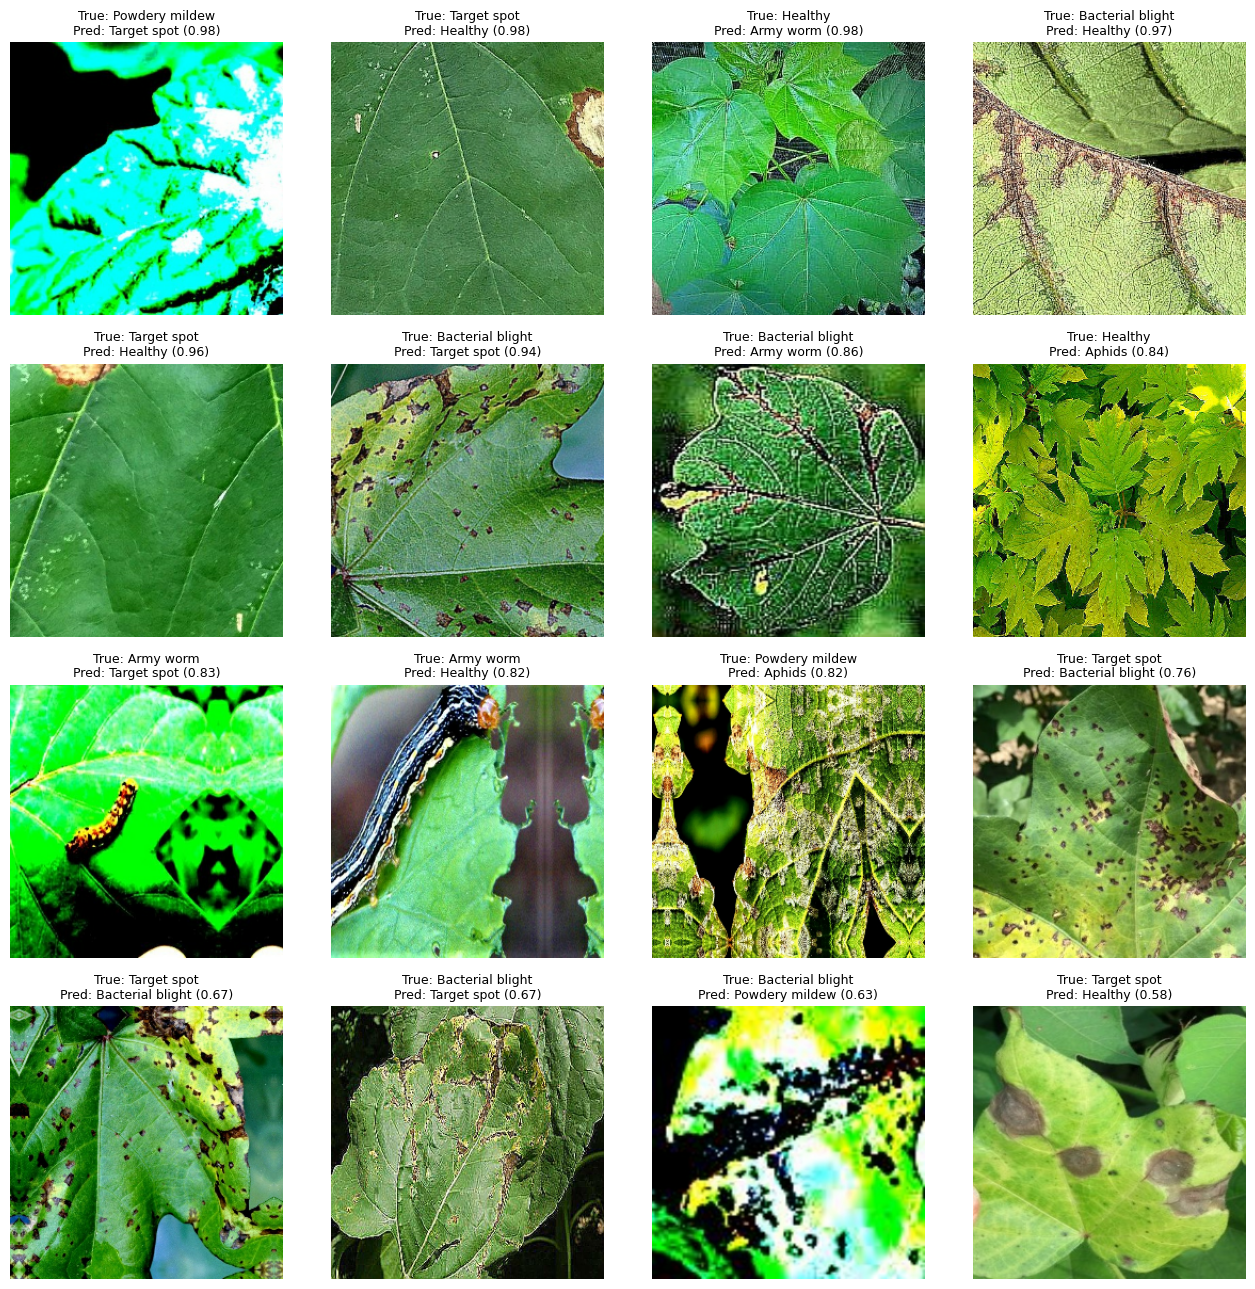

In [13]:
error_indices = np.where(y_true != y_pred)[0]
print("Test errors:", len(error_indices))

# Reconstruct the test images in the same order used for predictions.
test_images = []
for images, _ in test_dataset:
    test_images.append(images.numpy())
test_images = np.concatenate(test_images)

if len(error_indices) > 0:
    selected = error_indices[np.argsort(y_prob[error_indices].max(axis=1))[::-1]][:16]
    fig, axes = plt.subplots(4, 4, figsize=(13, 13))
    for ax in axes.flat:
        ax.axis("off")
    for ax, idx in zip(axes.flat, selected):
        ax.imshow(np.clip(test_images[idx] / 255.0, 0, 1))
        confidence = float(y_prob[idx].max())
        ax.set_title(
            f"True: {CLASS_NAMES[y_true[idx]]}\n"
            f"Pred: {CLASS_NAMES[y_pred[idx]]} ({confidence:.2f})",
            fontsize=9,
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 14. Save model, metrics, and evaluation artifacts


In [14]:
model_path = OUTPUT_DIR / "v1_original_cnn_final.keras"
model.save(model_path)

with open(OUTPUT_DIR / "class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump({key: float(value) for key, value in metrics.items()}, f, indent=2)

report_df.to_csv(OUTPUT_DIR / "classification_report.csv")
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(OUTPUT_DIR / "confusion_matrix.csv")
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

print("Saved model:", model_path)
print("Saved artifacts:", sorted(p.name for p in OUTPUT_DIR.iterdir()))


Saved model: /kaggle/working/cotton_v1_outputs/v1_original_cnn_final.keras
Saved artifacts: ['class_names.json', 'classification_report.csv', 'confusion_matrix.csv', 'metrics.json', 'training_history.csv', 'v1_original_cnn_best.keras', 'v1_original_cnn_final.keras']


## 15. Single-image inference helper


In [15]:
def predict_one(image_path, trained_model=model):
    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(image, channels=CHANNELS, expand_animations=False)
    image.set_shape([None, None, CHANNELS])
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE), antialias=True)
    probabilities = trained_model(tf.expand_dims(image, axis=0), training=False).numpy()[0]
    result = pd.DataFrame({
        "class": CLASS_NAMES,
        "probability": probabilities,
    })
    return result.sort_values("probability", ascending=False).reset_index(drop=True)

# Example:
# display(predict_one(DATA_ROOT / "Healthy" / "1.jpg"))


#### Experiment record

Record the test accuracy, balanced accuracy, macro-F1, weighted-F1, per-class recall, and normalized confusion matrix as the main experiment results. The experiment uses 4,788 total images with 3,840/480/468 train/validation/test image counts, six classes, 256×256 RGB images, and batch size 32.


## Executed experiment results

This section records the results from the run stored in this notebook.

### Configuration and data

| Item | Executed value |
|---|---:|
| Dataset | Cotton leaves / 40 Images |
| Total images | 4,788 |
| Classes | 6 |
| Images per class | Aphids 800; Army worm 800; Bacterial blight 800; Healthy 800; Powdery mildew 800; Target spot 788 |
| Image size | 256 × 256 RGB |
| Batch size | 32 |
| Training / validation / test | 3,840 / 480 / 468 images |
| Batches | 120 / 15 / 15 |
| Random seed | 123 |
| Augmentation | Random horizontal-and-vertical flip; random rotation factor 0.2 |
| Optimizer | Adam |
| Loss | Sparse categorical cross-entropy from logits=False |
| Maximum epochs | 100 |
| Early stopping | Monitored `val_loss`; patience 10; restored best weights |

### Model and training duration

The custom CNN contained **183,942 total trainable parameters** and no non-trainable parameters. The run completed **55 epochs** before early stopping. The best checkpoint was obtained at **epoch 45**, where validation accuracy was **0.9479** and validation loss was **0.1885**. Training stopped at epoch 55 after ten consecutive epochs without an improvement in validation loss, and the weights from epoch 45 were restored.

### Test-set results

The model evaluated all **468 test images** and produced **20 errors**.

| Metric | Score |
|---|---:|
| Accuracy | **0.9573** |
| Balanced accuracy | **0.9564** |
| Macro precision | **0.9568** |
| Macro recall | **0.9564** |
| Macro F1 | **0.9564** |
| Weighted precision | **0.9575** |
| Weighted recall | **0.9573** |
| Weighted F1 | **0.9572** |

### Per-class results

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Aphids | 0.9467 | 0.9861 | 0.9660 | 72 |
| Army worm | 0.9730 | 0.9600 | 0.9664 | 75 |
| Bacterial blight | 0.9577 | 0.9189 | 0.9379 | 74 |
| Healthy | 0.9425 | 0.9762 | 0.9591 | 84 |
| Powdery mildew | 0.9885 | 0.9773 | 0.9829 | 88 |
| Target spot | 0.9324 | 0.9200 | 0.9262 | 75 |

The strongest class-level F1-score was obtained for **Powdery mildew (0.9829)**. The lowest was for **Target spot (0.9262)**, followed by **Bacterial blight (0.9379)**. The close relationship between accuracy, balanced accuracy, macro-F1, and weighted-F1 indicates that performance was relatively consistent across classes, although Bacterial blight and Target spot were the most difficult categories in this run.
